# QRAM Tutorial - Bucket-Brigade Circuit And Simulation

This notebook introduces a compact QRAM workflow built around a bucket-brigade
circuit. A small executable example demonstrates the mechanism end to end, and
checked-in resource data is used to show how the requirements scale with QRAM
level.

The main example is deliberately small:

| Tutorial item | Scale used here | Why |
| --- | --- | --- |
| address register | 2 qubits | covers four memory cells: `00`, `01`, `10`, `11` |
| data cells | 4 classical bits | enough to verify address-dependent readout |
| bus register | 1 qubit | one-bit QRAM readout |
| router/data ancillas | generated by `buckdatacell.Qram` | exposes the bucket-brigade tree |
| core validation | local `Statevector` | exact readout probabilities without GPU |
| optional noise demo | CPU `Qiskit Aer` shots | illustrative noisy readout, not calibrated hardware |

The notebook does not reproduce the large calibrated noise simulations from the
project. Its goal is mechanism-level reproducibility: build a QRAM circuit,
verify the readout logic, compare CSWAP implementations, run a lightweight
noise demonstration, and inspect level-by-level resource trends.


In [1]:
%matplotlib inline

import os
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import qiskit
from IPython.display import display
from qiskit import ClassicalRegister, QuantumCircuit, QuantumRegister
from qiskit.quantum_info import Statevector


def discover_repo_root(start: Path) -> Path:
    anchor = start.resolve()
    for candidate in (anchor, *anchor.parents):
        if (candidate / "qram").is_dir() and (candidate / "realdata").is_dir():
            return candidate
        if (candidate / "QRAM" / "qram").is_dir() and (candidate / "QRAM" / "realdata").is_dir():
            return candidate / "QRAM"
    raise FileNotFoundError("Could not locate the QRAM repository root.")


repo_root = discover_repo_root(Path.cwd())
os.chdir(repo_root)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))


def ensure_qiskit_legacy_register_fields() -> None:
    # The original QRAM source was written against an older Qiskit API.
    if not hasattr(QuantumRegister, "_size"):
        QuantumRegister._size = property(lambda self: self.size)
    if not hasattr(ClassicalRegister, "_size"):
        ClassicalRegister._size = property(lambda self: self.size)


ensure_qiskit_legacy_register_fields()
warnings.filterwarnings("ignore", category=DeprecationWarning)

from qram.config import Config
from qram.qramtemplate.buckdatacell import (
    Qram as BucketBrigadeQram,
    cswap_depth,
    swap_depth,
)


def format_table(headers, rows):
    rows = [[str(item) for item in row] for row in rows]
    widths = [
        max(len(str(header)), *(len(row[idx]) for row in rows)) if rows else len(str(header))
        for idx, header in enumerate(headers)
    ]
    header = " | ".join(str(value).ljust(widths[idx]) for idx, value in enumerate(headers))
    rule = "-+-".join("-" * width for width in widths)
    body = [" | ".join(value.ljust(widths[idx]) for idx, value in enumerate(row)) for row in rows]
    return "\n".join([header, rule, *body])


def address_labels(n_address_qubits: int) -> list[str]:
    return [format(i, f"0{n_address_qubits}b") for i in range(2**n_address_qubits)]


def prepare_address_register(circuit: QuantumCircuit, address_qreg: QuantumRegister, state: str) -> None:
    if state == "uniform":
        for qubit in address_qreg:
            circuit.h(qubit)
        return

    if len(state) != len(address_qreg) or any(bit not in "01" for bit in state):
        raise ValueError("state must be 'uniform' or a bit string matching the address width.")

    for idx, bit in enumerate(state):
        if bit == "1":
            circuit.x(address_qreg[idx])


def build_bucket_qram(
    n_address_qubits: int,
    data: list[int],
    *,
    mode: str = "native",
    address_state: str = "uniform",
    include_measurements: bool = False,
    load_bus: bool = True,
):
    addresses = address_labels(n_address_qubits)
    if len(data) != len(addresses):
        raise ValueError("data length must equal 2 ** n_address_qubits")

    address_qreg = QuantumRegister(n_address_qubits, "address")
    bus_qreg = QuantumRegister(1, "bus")
    if include_measurements:
        c_address = ClassicalRegister(n_address_qubits, "c_address")
        c_bus = ClassicalRegister(1, "c_bus")
        circuit = QuantumCircuit(address_qreg, bus_qreg, c_address, c_bus)
    else:
        circuit = QuantumCircuit(address_qreg, bus_qreg)

    prepare_address_register(circuit, address_qreg, address_state)

    config = Config()
    config.decompose_mode = mode
    config.load_bus = load_bus
    config.dcswap_embedding = False

    qram = BucketBrigadeQram(addresses, data, bandwidth=1, config=config)
    qram(circuit, address_qreg, bus_qreg)

    if include_measurements:
        circuit.measure(bus_qreg, c_bus)
        circuit.measure(address_qreg, c_address)

    return circuit, qram, address_qreg, bus_qreg


def logical_readout_probabilities(
    circuit: QuantumCircuit,
    address_qreg: QuantumRegister,
    bus_qreg: QuantumRegister,
    *,
    threshold: float = 1e-10,
) -> pd.DataFrame:
    qargs = [circuit.find_bit(q).index for q in [*address_qreg, *bus_qreg]]
    raw = Statevector.from_instruction(circuit).probabilities_dict(qargs=qargs)

    rows = []
    for bitstring, probability in raw.items():
        # Qiskit displays classical bit strings with the highest-index bit first.
        # Reversing here makes the table read as address[0], address[1], ..., bus[0].
        logical_bits = str(bitstring)[::-1]
        rows.append(
            {
                "address": logical_bits[: len(address_qreg)],
                "bus": logical_bits[len(address_qreg) : len(address_qreg) + len(bus_qreg)],
                "probability": float(probability),
            }
        )

    df = pd.DataFrame(rows).groupby(["address", "bus"], as_index=False)["probability"].sum()
    df = df[df["probability"] > threshold]
    return df.sort_values(["address", "bus"]).reset_index(drop=True)


def expected_table(addresses: list[str], data: list[int], probability: float | None = None) -> pd.DataFrame:
    table = pd.DataFrame({"address": addresses, "expected_bus": [str(bit) for bit in data]})
    if probability is not None:
        table["expected_probability"] = probability
    return table


def resource_summary(circuit: QuantumCircuit) -> dict:
    return {
        "qubits": circuit.num_qubits,
        "clbits": circuit.num_clbits,
        "depth": circuit.depth(),
        "size": circuit.size(),
        "swap_depth": swap_depth(circuit),
        "cswap_or_cz_depth": cswap_depth(circuit),
        "ops": dict(circuit.count_ops()),
    }


print(
    format_table(
        ["item", "value"],
        [
            ["repo", str(repo_root)],
            ["qiskit", qiskit.__version__],
            ["core simulator", "qiskit.quantum_info.Statevector"],
            ["optional noisy simulator", "qiskit_aer.AerSimulator"],
            ["tutorial scale", "2 address qubits, 4 cells, 1 bus qubit"],
        ],
    )
)


item                     | value                                 
-------------------------+---------------------------------------
repo                     | D:\Desktop\Quantum\QRAM\project\QRAM  
qiskit                   | 2.2.3                                 
core simulator           | qiskit.quantum_info.Statevector       
optional noisy simulator | qiskit_aer.AerSimulator               
tutorial scale           | 2 address qubits, 4 cells, 1 bus qubit


## 1. Define A Small QRAM Instance

QRAM implements address-dependent data readout as a quantum circuit. This
tutorial uses 2 address qubits, which represent 4 memory cells, and stores a
small Boolean table:

`00 -> 0`, `01 -> 1`, `10 -> 1`, `11 -> 0`

This data pattern is useful for a tutorial because it is not all-zero or
all-one, so the readout must depend on the address. The circuit is still small
enough to verify each address directly with a statevector simulation.


In [2]:
n_address_qubits = 2
memory_data = [0, 1, 1, 0]
addresses = address_labels(n_address_qubits)

memory_table = expected_table(addresses, memory_data)
print("Memory table used by the QRAM example")
display(memory_table)


Memory table used by the QRAM example


,address,expected_bus
0,00,0
1,01,1
2,10,1
3,11,0


## 2. Build The Bucket-Brigade Circuit

The bucket-brigade implementation used here lives in
`qram/qramtemplate/buckdatacell.py`. Given the address width, it generates a
router tree and attaches the auxiliary qubits required by the QRAM routing
procedure.

| Register role | Meaning |
| --- | --- |
| `address` | the query address, either a basis state or a superposition |
| `bus` | the readout qubit that carries the selected data bit |
| `incident` | a work qubit used during bucket-brigade routing |
| `router_*` | router nodes and leaves that guide the bus through the tree |
| `router_*_data` | leaf data qubits used by CZ operations to encode classical data |

The first example prepares the address register in a uniform superposition, so
one statevector simulation covers all four addresses at once.


In [3]:
bucket_circuit, bucket_qram, address_qreg, bus_qreg = build_bucket_qram(
    n_address_qubits,
    memory_data,
    mode="native",
    address_state="uniform",
)

summary = resource_summary(bucket_circuit)
print("Circuit resource summary for the native bucket-brigade QRAM")
display(pd.DataFrame([summary]).drop(columns=["ops"]))
print("Gate counts in the generated QRAM circuit")
display(pd.DataFrame([{"gate": gate, "count": count} for gate, count in summary["ops"].items()]))

register_rows = []
for qreg in bucket_circuit.qregs:
    if qreg.name == "address":
        role = "query address"
    elif qreg.name == "bus":
        role = "readout bus"
    elif qreg.name == "incident":
        role = "routing work qubit"
    elif qreg.name.endswith("_data"):
        role = "leaf data cell"
    elif "router" in qreg.name:
        role = "router tree node"
    else:
        role = "other"
    register_rows.append({"register": qreg.name, "size": qreg.size, "role": role})

print("Quantum registers introduced by the QRAM construction")
display(pd.DataFrame(register_rows))
print("Text drawing of the generated QRAM circuit")
print(bucket_circuit.draw(output="text", fold=120))


Circuit resource summary for the native bucket-brigade QRAM


,qubits,clbits,depth,size,swap_depth,cswap_or_cz_depth
0,9,0,26,32,8,8


Gate counts in the generated QRAM circuit


,gate,count
0,x,10
1,swap,8
2,cswap,8
3,barrier,7
4,h,4
5,cz,2


Quantum registers introduced by the QRAM construction


,register,size,role
0,address,2,query address
1,bus,1,readout bus
2,incident,1,routing work qubit
3,router_0,1,router tree node
4,router_1_0,1,router tree node
5,router_1_0_data,1,leaf data cell
6,router_1_1,1,router tree node
7,router_1_1_data,1,leaf data cell


Text drawing of the generated QRAM circuit
                 ┌───┐       ░                  ░                  ░               ░                     ░            »
      address_0: ┤ H ├─X─────░──────────────────░──────────────────░───────────────░─────────────────────░────────────»
                 ├───┤ │     ░                  ░                  ░               ░                     ░            »
      address_1: ┤ H ├─┼─────░───X──────────────░──────────────────░───────────────░─────────────────────░────────────»
                 ├───┤ │     ░   │              ░                  ░               ░                     ░            »
            bus: ┤ H ├─┼─────░───┼──────────────░───X──────────────░───────────────░──────────────────X──░────────────»
                 └───┘ │     ░   │              ░   │              ░               ░                  │  ░            »
       incident: ──────X──X──░───X───X───────X──░───X───X───────X──░───────────────░───────X───────X──X──░──X───────X

## 3. Simulate QRAM Readout

The ideal one-bit QRAM transformation is:

$$
\sum_a \alpha_a \lvert a\rangle \lvert 0\rangle_{\mathrm{bus}}
\longrightarrow
\sum_a \alpha_a \lvert a\rangle \lvert d_a\rangle_{\mathrm{bus}}
$$

Because the address register is uniform, each address should appear with
probability `1/4`. The table below marginalizes the full statevector down to
`address + bus`, leaving the router and data ancillas out of the display.


In [4]:
readout = logical_readout_probabilities(bucket_circuit, address_qreg, bus_qreg)

expected = expected_table(addresses, memory_data, probability=1 / len(addresses))
comparison = expected.merge(
    readout,
    left_on=["address", "expected_bus"],
    right_on=["address", "bus"],
    how="left",
)
comparison["probability"] = comparison["probability"].fillna(0.0)
comparison["abs_delta"] = (
    comparison["probability"] - comparison["expected_probability"]
).abs()

print("Statevector readout check against the expected memory table")
display(comparison[["address", "expected_bus", "expected_probability", "probability", "abs_delta"]])
print(f"L1 error on expected rows: {comparison['abs_delta'].sum():.3e}")


Statevector readout check against the expected memory table


,address,expected_bus,expected_probability,probability,abs_delta
0,00,0,0.25,0.25,1.665335e-16
1,01,1,0.25,0.25,1.665335e-16
2,10,1,0.25,0.25,1.665335e-16
3,11,0,0.25,0.25,1.665335e-16


L1 error on expected rows: 6.661e-16


## 4. Query One Classical Address

The previous cell verifies a superposition of addresses. For a more direct
readout example, this cell prepares the classical address `10`. Since the memory
table stores `10 -> 1`, the final bus qubit should be `1` with probability 1.


In [5]:
query_address = "10"
query_circuit, _, query_address_qreg, query_bus_qreg = build_bucket_qram(
    n_address_qubits,
    memory_data,
    mode="native",
    address_state=query_address,
)

query_readout = logical_readout_probabilities(query_circuit, query_address_qreg, query_bus_qreg)
print(f"Readout distribution for the classical query address {query_address}")
display(query_readout)


Readout distribution for the classical query address 10


,address,bus,probability
0,10,1,1.0


## 5. Compare CSWAP Implementations

Controlled-SWAP is the key routing primitive in bucket-brigade QRAM. The source
tree exposes three implementation paths:

| Mode | Source behavior |
| --- | --- |
| `native` | use Qiskit's native `cswap` gate |
| `cswap_decompose` | expand CSWAP into an `rx/rz/cz` sequence |
| `subspace_decompose` | use a shorter subspace decomposition sequence |

The next cell compares the resource cost of the three modes on the same
2-address QRAM instance and checks that the readout probabilities remain close
to the ideal table.


In [6]:
mode_rows = []
readout_rows = []

for mode in ["native", "cswap_decompose", "subspace_decompose"]:
    circuit, _, a_qreg, b_qreg = build_bucket_qram(
        n_address_qubits,
        memory_data,
        mode=mode,
        address_state="uniform",
    )
    summary = resource_summary(circuit)
    mode_rows.append(
        {
            "mode": mode,
            "qubits": summary["qubits"],
            "depth": summary["depth"],
            "size": summary["size"],
            "swap_depth": summary["swap_depth"],
            "cswap_or_cz_depth": summary["cswap_or_cz_depth"],
            "ops": summary["ops"],
        }
    )

    mode_readout = logical_readout_probabilities(circuit, a_qreg, b_qreg)
    mode_comparison = expected.merge(
        mode_readout,
        left_on=["address", "expected_bus"],
        right_on=["address", "bus"],
        how="left",
    )
    mode_comparison["probability"] = mode_comparison["probability"].fillna(0.0)
    mode_comparison["abs_delta"] = (
        mode_comparison["probability"] - mode_comparison["expected_probability"]
    ).abs()
    readout_rows.append(
        {
            "mode": mode,
            "max_abs_delta": mode_comparison["abs_delta"].max(),
            "l1_error": mode_comparison["abs_delta"].sum(),
        }
    )

print("Resource comparison across CSWAP implementation modes")
display(pd.DataFrame(mode_rows))
print("Statevector readout error for each implementation mode")
display(pd.DataFrame(readout_rows))


Resource comparison across CSWAP implementation modes


,mode,qubits,depth,size,swap_depth,cswap_or_cz_depth,ops
0,native,9,26,32,8,8,"{'x': 10, 'swap': 8, 'cswap': 8, 'barrier': 7,..."
1,cswap_decompose,9,229,352,72,64,"{'rx': 136, 'rz': 128, 'cz': 66, 'x': 10, 'swa..."
2,subspace_decompose,9,133,216,48,40,"{'rx': 96, 'rz': 56, 'cz': 42, 'x': 10, 'swap'..."


Statevector readout error for each implementation mode


,mode,max_abs_delta,l1_error
0,native,1.665335e-16,6.661338e-16
1,cswap_decompose,1.686046e-05,5.559831e-05
2,subspace_decompose,2.483340e-05,6.595277e-05


## 6. Optional: Noisy Readout With Qiskit Aer

The previous sections use exact statevector simulation. A lightweight noisy
experiment is also useful, but it requires two extra choices:

1. the QRAM circuit must include measurements, because Aer shot simulation
   returns classical counts;
2. the noise model should be attached to gates that the simulator executes.

This example uses the `subspace_decompose` circuit because it is already
expressed with one- and two-qubit gates (`rx`, `rz`, `cz`, `swap`) instead of
native three-qubit `cswap` gates. The noise model below is intentionally simple:
small depolarizing errors on one- and two-qubit gates plus a symmetric readout
error. It is a tutorial model, not a calibrated hardware model.

The default parameters used below are:

| Parameter | Value | Applied to |
| --- | ---: | --- |
| `p1` | `0.001` | one-qubit gate depolarizing error |
| `p2` | `0.01` | two-qubit gate depolarizing error |
| `p_readout` | `0.02` | symmetric measurement readout error |
| `aer_seed` | `20` | reproducible shot and noise sampling |


In [7]:
from qiskit import transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, ReadoutError, depolarizing_error


def make_tutorial_noise_model(p1=0.001, p2=0.01, p_readout=0.02):
    noise_model = NoiseModel()
    noise_model.add_all_qubit_quantum_error(
        depolarizing_error(p1, 1),
        ["x", "h", "rx", "rz"],
    )
    noise_model.add_all_qubit_quantum_error(
        depolarizing_error(p2, 2),
        ["cz", "cx", "swap"],
    )
    noise_model.add_all_qubit_readout_error(
        ReadoutError([[1 - p_readout, p_readout], [p_readout, 1 - p_readout]])
    )
    return noise_model


def parse_aer_counts(counts):
    rows = []
    total = sum(counts.values())
    for bitstring, shots in counts.items():
        compact = bitstring.replace(" ", "")
        # Qiskit prints classical registers in reverse register order here:
        # c_bus appears before c_address, and c_address bits are reversed.
        bus = compact[0]
        address = compact[1:][::-1]
        rows.append(
            {
                "address": address,
                "bus": bus,
                "shots": shots,
                "probability": shots / total,
            }
        )
    return (
        pd.DataFrame(rows)
        .groupby(["address", "bus"], as_index=False)[["shots", "probability"]]
        .sum()
        .sort_values(["address", "bus"])
        .reset_index(drop=True)
    )


def readout_success_probability(distribution, data):
    expected_bus = {address: str(bit) for address, bit in zip(addresses, data)}
    return float(
        distribution[
            distribution.apply(lambda row: expected_bus[row["address"]] == row["bus"], axis=1)
        ]["probability"].sum()
    )


aer_circuit, _, _, _ = build_bucket_qram(
    n_address_qubits,
    memory_data,
    mode="subspace_decompose",
    address_state="uniform",
    include_measurements=True,
)

basis_gates = ["rx", "rz", "x", "h", "cz", "cx", "swap", "measure"]
aer_circuit = transpile(aer_circuit, basis_gates=basis_gates, optimization_level=0)

shots = 4096
aer_seed = 20
ideal_backend = AerSimulator(seed_simulator=aer_seed)
noisy_backend = AerSimulator(
    noise_model=make_tutorial_noise_model(),
    seed_simulator=aer_seed,
)

ideal_counts = ideal_backend.run(aer_circuit, shots=shots).result().get_counts()
noisy_counts = noisy_backend.run(aer_circuit, shots=shots).result().get_counts()

ideal_distribution = parse_aer_counts(ideal_counts)
noisy_distribution = parse_aer_counts(noisy_counts)

print("Measured Aer circuit resource summary")
display(pd.DataFrame([resource_summary(aer_circuit)]).drop(columns=["ops"]))
print("Ideal Aer shot distribution")
display(ideal_distribution)
print("Noisy Aer shot distribution")
display(noisy_distribution)

success_rows = pd.DataFrame(
    [
        {
            "simulation": "Aer ideal shots",
            "success_probability": readout_success_probability(ideal_distribution, memory_data),
        },
        {
            "simulation": "Aer noisy shots",
            "success_probability": readout_success_probability(noisy_distribution, memory_data),
        },
    ]
)
print("Readout success probability from Aer shot simulations")
display(success_rows)


Measured Aer circuit resource summary

,qubits,clbits,depth,size,swap_depth,cswap_or_cz_depth
0,9,3,134,219,48,40


Ideal Aer shot distribution


,address,bus,shots,probability
0,00,0,1036,0.252930
1,01,1,1012,0.247070
2,10,1,1029,0.251221
3,11,0,1019,0.248779


Noisy Aer shot distribution


,address,bus,shots,probability
0,00,0,847,0.206787
1,00,1,212,0.051758
2,01,0,191,0.046631
3,01,1,810,0.197754
4,10,0,221,0.053955
5,10,1,832,0.203125
6,11,0,803,0.196045
7,11,1,180,0.043945


Readout success probability from Aer shot simulations


,simulation,success_probability
0,Aer ideal shots,1.000000
1,Aer noisy shots,0.803711


## 7. Inspect Scaling Data Already In The Repository

Large QRAM statevector or density-matrix simulations become expensive quickly.
To keep this tutorial lightweight and reproducible, this section uses the
resource CSV files already checked into the repository. They show how qubit
count, SWAP/CSWAP depth, and mapping resources grow with the QRAM level.

The files are under `realdata/data/depth_gate/`:

| File | Meaning |
| --- | --- |
| `counts_data.csv` | resource statistics for the data-load QRAM circuit |
| `counts_nodedataload.csv` | resource statistics without data loading |
| `h_tree.csv` | teleportation and SWAP statistics for H-tree mapping |

In these CSV files, `counts_data.csv` and `counts_nodedataload.csv` use the
same qubit allocation for each QRAM level, so their qubit-count curves overlap.
The difference appears in depth and gate counts rather than in `num_qubits`.


Data-load QRAM resource data, first seven levels


,level,num_qubits,swap_depth,cswap_depth,cswap_count,swap_count,h_count,x_count
0,1,3,0,0,0,0,2,2
1,2,9,8,8,8,8,2,8
2,3,18,10,18,28,14,5,28
3,4,35,12,28,72,24,6,72
4,5,68,14,38,164,42,7,164
5,6,133,16,48,352,76,8,352
6,7,262,18,58,732,142,9,732


No-data-load QRAM resource data, first seven levels


,level,num_qubits,swap_depth,cswap_depth,cswap_count,swap_count,h_count,x_count
0,1,3,0,0,0,0,2,2
1,2,9,7,6,6,7,3,6
2,3,18,9,15,22,13,8,22
3,4,35,11,25,58,23,13,58
4,5,68,13,35,134,41,22,134
5,6,133,15,45,290,75,39,290
6,7,262,17,55,606,141,72,606


H-tree mapping resource data, first seven levels


,level,tele_count,swap_count,tele_depth,swap_depth
0,1,0,0.0,0,0.0
1,2,0,2.0,0,2.0
2,3,12,6.0,12,6.0
3,4,24,16.0,24,16.0
4,5,60,50.0,40,40.0
5,6,192,156.0,84,96.0
6,7,504,434.0,140,196.0


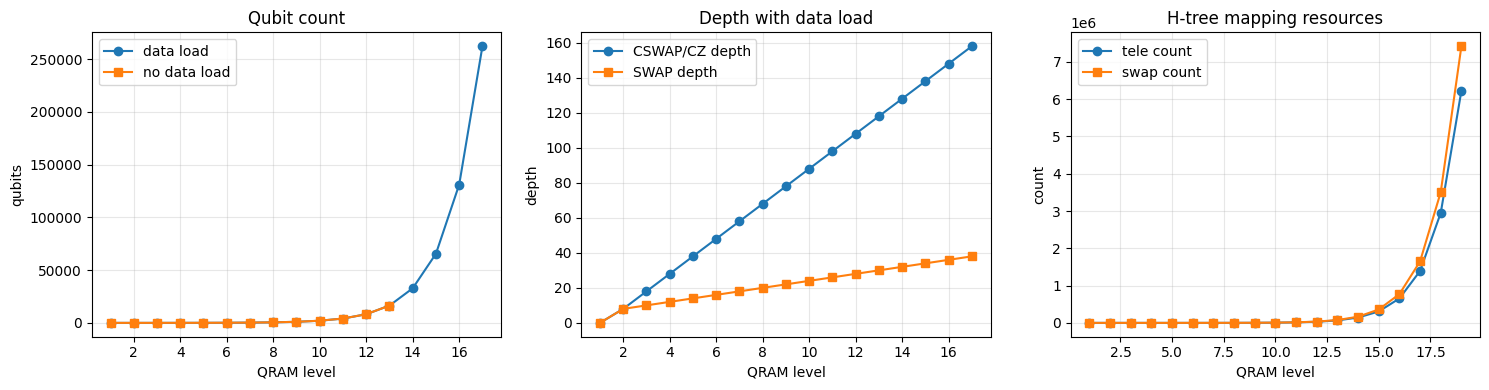

In [8]:
depth_dir = repo_root / "realdata" / "data" / "depth_gate"
counts_data = pd.read_csv(depth_dir / "counts_data.csv")
counts_noload = pd.read_csv(depth_dir / "counts_nodedataload.csv")
h_tree = pd.read_csv(depth_dir / "h_tree.csv")

print("Data-load QRAM resource data, first seven levels")
display(counts_data.head(7))
print("No-data-load QRAM resource data, first seven levels")
display(counts_noload.head(7))
print("H-tree mapping resource data, first seven levels")
display(h_tree.head(7))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(counts_data["level"], counts_data["num_qubits"], marker="o", label="data load")
axes[0].plot(counts_noload["level"], counts_noload["num_qubits"], marker="s", label="no data load")
axes[0].set_xlabel("QRAM level")
axes[0].set_ylabel("qubits")
axes[0].set_title("Qubit count")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(counts_data["level"], counts_data["cswap_depth"], marker="o", label="CSWAP/CZ depth")
axes[1].plot(counts_data["level"], counts_data["swap_depth"], marker="s", label="SWAP depth")
axes[1].set_xlabel("QRAM level")
axes[1].set_ylabel("depth")
axes[1].set_title("Depth with data load")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(h_tree["level"], h_tree["tele_count"], marker="o", label="tele count")
axes[2].plot(h_tree["level"], h_tree["swap_count"], marker="s", label="swap count")
axes[2].set_xlabel("QRAM level")
axes[2].set_ylabel("count")
axes[2].set_title("H-tree mapping resources")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## What This Notebook Demonstrated

1. Built a small bucket-brigade QRAM instance with 2 address qubits, 4 memory
   cells, and 1 bus qubit.
2. Explained the roles of `address`, `bus`, `incident`, `router_*`, and
   `router_*_data` registers.
3. Verified QRAM readout on an address superposition with local `Statevector`
   simulation.
4. Demonstrated a direct classical query for address `10`.
5. Compared native CSWAP, full CSWAP decomposition, and subspace decomposition
   in terms of depth, gate counts, and statevector probability error.
6. Ran a lightweight optional Qiskit Aer experiment with depolarizing and
   readout noise, reporting the readout success probability.
7. Used repository CSV files to inspect how QRAM resources scale with the
   circuit level.

A natural extension is to turn the GPU density-matrix simulations under
`simulations/` into a second notebook. This first tutorial stays lightweight,
fast, and easy to review.
